# **IMPORT LIBRARIES & Read Datasets**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set(style="whitegrid")

In [2]:
ball_by_ball = pd.read_csv(
    "IPL_BallByBall2008_2024(Updated).csv",
    low_memory=False
)
team_perf = pd.read_csv("team_performance_dataset_2008to2024.csv")
players = pd.read_csv("Players_Info_2024.csv")
teams = pd.read_csv("ipl_teams_2024_info.csv")


In [3]:
ball_by_ball.head()


,Match id,Date,Season,Batting team,Bowling team,Innings No,Ball No,Bowler,Striker,Non Striker,runs_scored,extras,type of extras,score,score/wicket,wicket_confirmation,wicket_type,fielders_involved,Player Out
0,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.1,P Kumar,SC Ganguly,BB McCullum,0,1,legbyes,1,1/0,0,NaN,NaN,NaN
1,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.2,P Kumar,BB McCullum,SC Ganguly,0,0,NaN,1,1/0,0,NaN,NaN,NaN
2,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.2,P Kumar,BB McCullum,SC Ganguly,0,1,wides,2,2/0,0,NaN,NaN,NaN
3,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.3,P Kumar,BB McCullum,SC Ganguly,0,0,NaN,2,2/0,0,NaN,NaN,NaN
4,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.4,P Kumar,BB McCullum,SC Ganguly,0,0,NaN,2,2/0,0,NaN,NaN,NaN


In [4]:
ball_by_ball.shape


(255759, 19)

# **Dataset Cleaning**

In [5]:
import pandas as pd
import numpy as np

def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

ball_by_ball = clean_columns(ball_by_ball)
team_perf = clean_columns(team_perf)
players = clean_columns(players)
teams = clean_columns(teams)

ball_by_ball.dropna(how="all", inplace=True)
team_perf.dropna(how="all", inplace=True)
players.dropna(how="all", inplace=True)
teams.dropna(how="all", inplace=True)

team_mapping = {
    "delhi_daredevils": "delhi_capitals",
    "deccan_chargers": "sunrisers_hyderabad",
    "rising_pune_supergiant": "rising_pune_supergiants",
    "gujarat_lions": "defunct",
    "kochi_tuskers_kerala": "defunct",
    "pune_warriors": "defunct"
}

def normalize_teams(df):
    for col in df.columns:
        if "team" in col or col in ["winner"]:
            df[col] = (
                df[col]
                .astype(str)
                .str.lower()
                .str.replace(" ", "_")
                .replace(team_mapping)
            )
    return df

ball_by_ball = normalize_teams(ball_by_ball)
team_perf = normalize_teams(team_perf)
players = normalize_teams(players)
teams = normalize_teams(teams)

possible_team1_cols = ["team1", "team_1", "home_team"]
possible_team2_cols = ["team2", "team_2", "away_team"]

team1_col = next((c for c in possible_team1_cols if c in team_perf.columns), None)
team2_col = next((c for c in possible_team2_cols if c in team_perf.columns), None)

if team1_col and team2_col:
    team_perf = team_perf[
        (~team_perf[team1_col].isin(["defunct"])) &
        (~team_perf[team2_col].isin(["defunct"]))
    ]

numeric_ball_cols = [
    "runs_scored", "extras", "innings_no", "over", "ball"
]

for col in numeric_ball_cols:
    if col in ball_by_ball.columns:
        ball_by_ball[col] = pd.to_numeric(
            ball_by_ball[col], errors="coerce"
        )

if "winner" in team_perf.columns:
    team_perf = team_perf[team_perf["winner"].notna()]

ball_by_ball.reset_index(drop=True, inplace=True)
team_perf.reset_index(drop=True, inplace=True)
players.reset_index(drop=True, inplace=True)
teams.reset_index(drop=True, inplace=True)

ball_by_ball.to_csv("clean_ball_by_ball.csv", index=False)
team_perf.to_csv("clean_team_performance.csv", index=False)
players.to_csv("clean_players_info.csv", index=False)
teams.to_csv("clean_teams_info.csv", index=False)

print("All datasets are cleaned successfully.")

All datasets are cleaned successfully.


In [6]:
raw_ball = pd.read_csv(
    "IPL_BallByBall2008_2024(Updated).csv",
    low_memory=False
)
raw_team = pd.read_csv("team_performance_dataset_2008to2024.csv")
raw_players = pd.read_csv("Players_Info_2024.csv")
raw_teams = pd.read_csv("ipl_teams_2024_info.csv")

In [7]:
clean_ball = pd.read_csv("clean_ball_by_ball.csv", low_memory=False)
clean_team = pd.read_csv("clean_team_performance.csv")
clean_players = pd.read_csv("clean_players_info.csv")
clean_teams = pd.read_csv("clean_teams_info.csv")

In [8]:
print("Comparison Table(Before vs After)\n")

shape_comparison = pd.DataFrame({
    "Dataset": [
        "Ball-by-ball",
        "Team performance",
        "Players info",
        "Teams info"
    ],
    "Raw Shape": [
        raw_ball.shape,
        raw_team.shape,
        raw_players.shape,
        raw_teams.shape
    ],
    "Cleaned Shape": [
        clean_ball.shape,
        clean_team.shape,
        clean_players.shape,
        clean_teams.shape
    ]
})

shape_comparison

Comparison Table(Before vs After)



,Dataset,Raw Shape,Cleaned Shape
0,Ball-by-ball,"(255759, 19)","(255759, 19)"
1,Team performance,"(1073, 18)","(1073, 18)"
2,Players info,"(245, 10)","(245, 10)"
3,Teams info,"(10, 7)","(10, 7)"


In [9]:
print("\nBALL-BY-BALL COLUMNS:")
print(clean_ball.columns.tolist())

print("\nTEAM PERFORMANCE COLUMNS:")
print(clean_team.columns.tolist())


BALL-BY-BALL COLUMNS:
['match_id', 'date', 'season', 'batting_team', 'bowling_team', 'innings_no', 'ball_no', 'bowler', 'striker', 'non_striker', 'runs_scored', 'extras', 'type_of_extras', 'score', 'score/wicket', 'wicket_confirmation', 'wicket_type', 'fielders_involved', 'player_out']

TEAM PERFORMANCE COLUMNS:
['match_id', 'date', 'teams', 'venue', 'toss_winner', 'toss_decision', 'match_winner', 'win_type', 'win_margin', 'first_innings_score', 'second_innings_score', 'player_of_match', 'umpire', 'umpire1', 'umpire2', 'powerplay_scores', 'middle_overs_scores', 'death_overs_scores']


In [10]:
print(sorted(clean_ball["batting_team"].dropna().unique())[:10])
print(sorted(clean_team["match_winner"].dropna().unique())[:10])


['chennai_super_kings', 'defunct', 'delhi_capitals', 'gujarat_titans', 'kings_xi_punjab', 'kolkata_knight_riders', 'lucknow_super_giants', 'mumbai_indians', 'punjab_kings', 'rajasthan_royals']
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Draw/No Result', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders']


# **EDA 1: Macro IPL Trends (2008–2024)**


**1️A.Total Runs per Season**

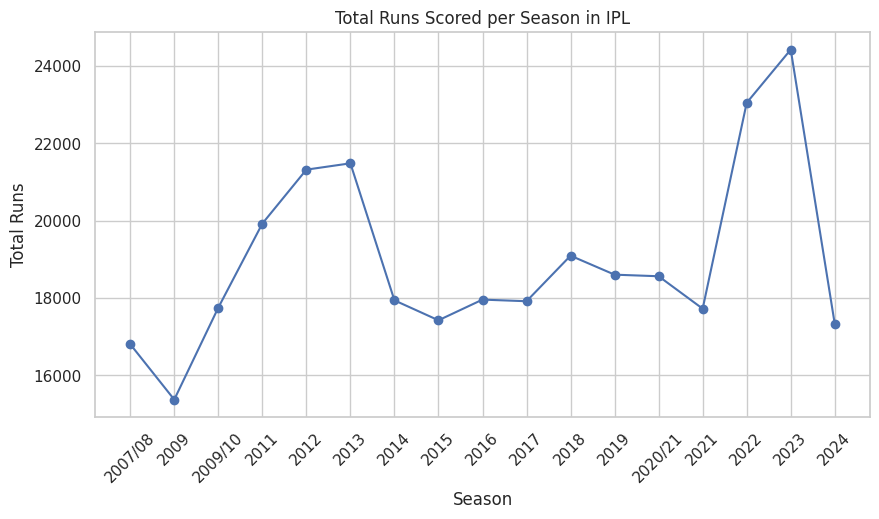

In [11]:
season_runs = (
    clean_ball
    .groupby("season")["runs_scored"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(season_runs["season"], season_runs["runs_scored"], marker="o")
plt.title("Total Runs Scored per Season in IPL")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()


**1B.Average Runs per Match per Season**

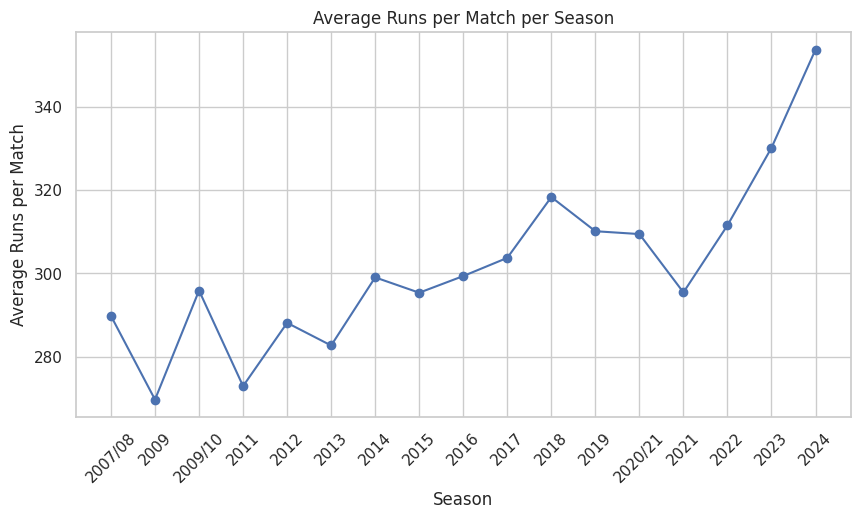

In [12]:
runs_per_match = (
    clean_ball
    .groupby(["season", "match_id"])["runs_scored"]
    .sum()
    .reset_index()
    .groupby("season")["runs_scored"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(runs_per_match["season"], runs_per_match["runs_scored"], marker="o")
plt.title("Average Runs per Match per Season")
plt.xlabel("Season")
plt.ylabel("Average Runs per Match")
plt.xticks(rotation=45)
plt.show()

**1C.Number of Matches per Season**

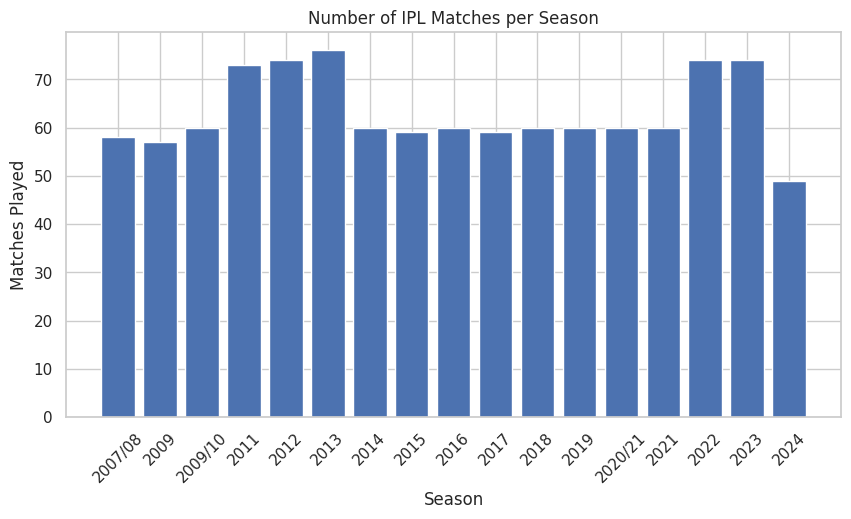

In [13]:
matches_per_season = (
    clean_ball
    .groupby("season")["match_id"]
    .nunique()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(matches_per_season["season"], matches_per_season["match_id"])
plt.title("Number of IPL Matches per Season")
plt.xlabel("Season")
plt.ylabel("Matches Played")
plt.xticks(rotation=45)
plt.show()

# **Insights**


* **IPL has become progressively more high-scoring, with a clear
upward trend in both total runs and average runs per match, especially after the mid-2010s.**

* **Recent seasons show higher scoring efficiency, indicating improved batting depth, flatter pitches, and impact of rule changes.**

* **Variations in total runs across seasons are partly driven by the number of matches played, highlighting the importance of normalizing metrics before comparisons.**

# **EDA 2: Team Dominance & Consistency**



**2A.Overall Wins by Team (All Seasons)**

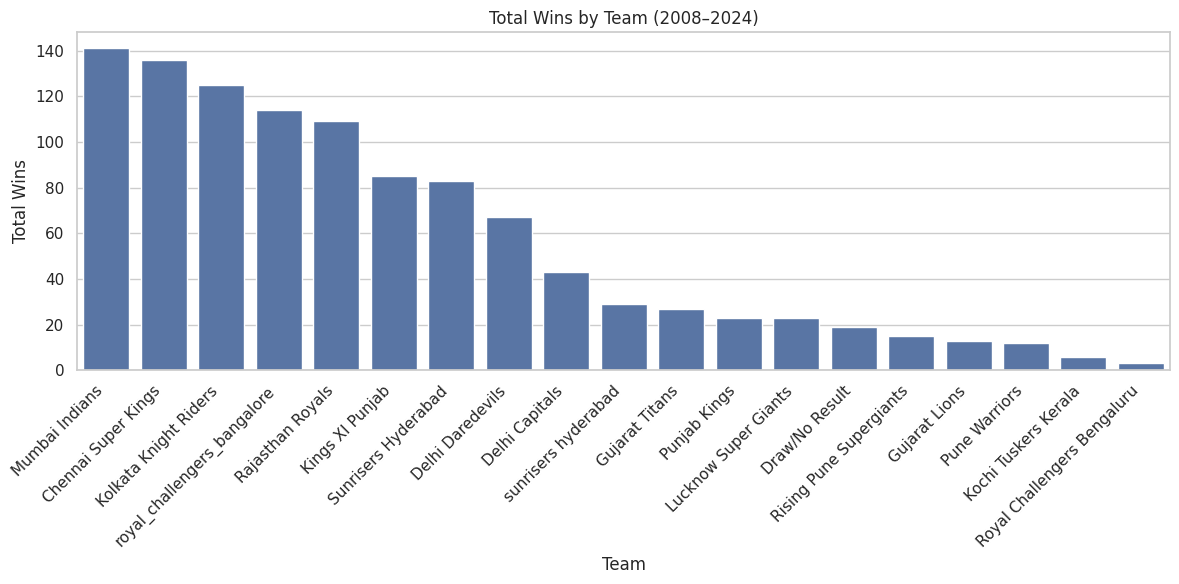

In [14]:
possible_winner_cols = [
    "winner", "winning_team", "match_winner", "team_won", "won_by"
]

winner_col = next(
    (c for c in possible_winner_cols if c in clean_team.columns),
    None
)

canonical_team_mapping = {
    "Royal_challengers_bangalore": "royal challengers bengaluru",
    "delhi daredevils": "delhi capitals",
    "deccan_chargers": "sunrisers hyderabad",
    "rising_pune_supergiant": "Rising Pune Supergiants",
    "delhi_daredevils": "Delhi Daredevils",
    "kolkata_knight_riders": "Kolkata Knight Riders",
    "chennai_super_kings": "Chennai Super Kings",
    "mumbai_indians": "Mumbai Indians",
    "lucknow_super_giants": "Lucknow Super Giants",
    "rising_pune_supergiants": "Rising Pune Supergiants",
    "sunrisers_hyderabad": "Sunrisers Hyderabad",
    "kings_xi_punjab": "Kings XI Punjab",
    "rajasthan_royals": "Rajasthan Royals",
    "delhi_capitals": "Delhi Capitals",
    "royal_challengers_bengaluru": "Royal Challengers Bengaluru",
    "gujarat_lions": "Gujarat Lions",
    "kochi_tuskers_kerala": "Kochi Tuskers Kerala",
    "pune_warriors": "Pune Warriors",
    "draw/no_result": "Draw/No Result",
    "punjab_kings": "Punjab Kings",
    "gujarat_titans": "Gujarat Titans",

}
clean_team[winner_col] = (
    clean_team[winner_col]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .replace(canonical_team_mapping)
)
team_wins = (
    clean_team
    .groupby(winner_col)["match_id"]
    .count()
    .reset_index()
    .rename(columns={
        winner_col: "team",
        "match_id": "wins"
    })
    .sort_values(by="wins", ascending=False)
)
plt.figure(figsize=(12,6))
sns.barplot(data=team_wins, x="team", y="wins")
plt.title("Total Wins by Team (2008–2024)")
plt.xlabel("Team")
plt.ylabel("Total Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**2B.Wins by Team per Season**

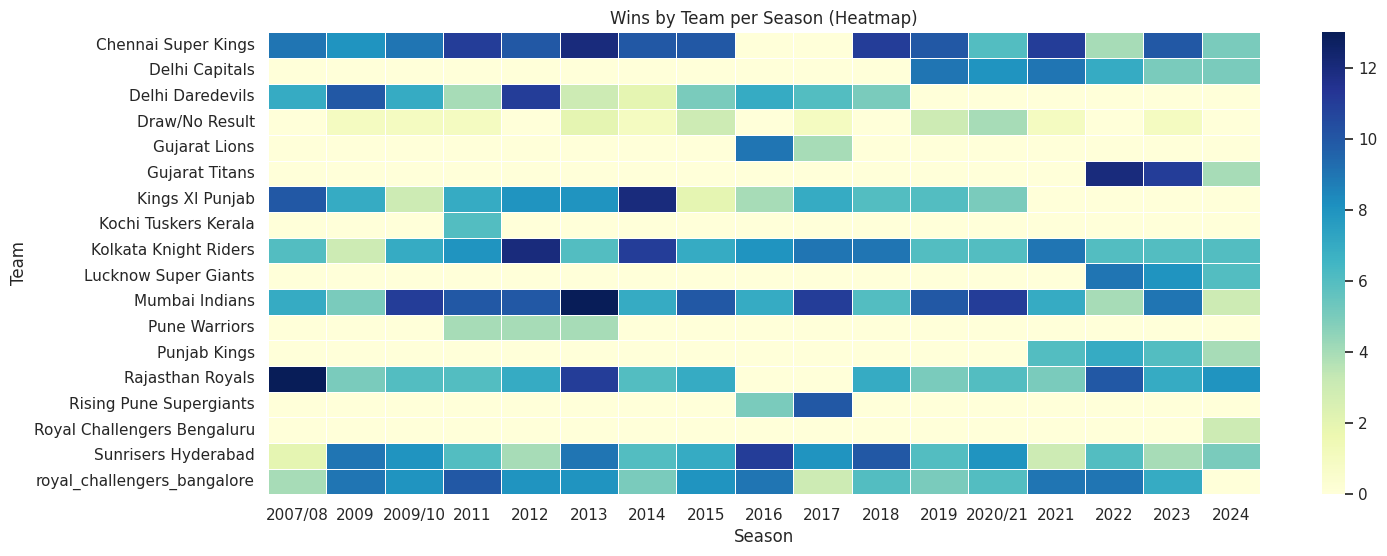

In [15]:
possible_winner_cols = [
    "winner", "winning_team", "match_winner", "team_won", "won_by"
]

winner_col = next(
    (c for c in possible_winner_cols if c in clean_team.columns),
    None
)

canonical_team_mapping = {
    "delhi_daredevils": "Delhi Daredevils",
    "kolkata_knight_riders": "Kolkata Knight Riders",
    "chennai_super_kings": "Chennai Super Kings",
    "mumbai_indians": "Mumbai Indians",
    "lucknow_super_giants": "Lucknow Super Giants",
    "rising_pune_supergiants": "Rising Pune Supergiants",
    "sunrisers_hyderabad": "Sunrisers Hyderabad",
    "kings_xi_punjab": "Kings XI Punjab",
    "rajasthan_royals": "Rajasthan Royals",
    "delhi_capitals": "Delhi Capitals",
    "royal_challengers_bengaluru": "Royal Challengers Bengaluru",
    "gujarat_lions": "Gujarat Lions",
    "kochi_tuskers_kerala": "Kochi Tuskers Kerala",
    "pune_warriors": "Pune Warriors",
    "draw/no_result": "Draw/No Result",
    "punjab_kings": "Punjab Kings",
    "gujarat_titans": "Gujarat Titans",
}

clean_team[winner_col] = (
    clean_team[winner_col]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .replace(canonical_team_mapping)
)

match_season_mapping = clean_ball[['match_id', 'season']].drop_duplicates()
clean_team_with_season = pd.merge(
    clean_team,
    match_season_mapping,
    on='match_id',
    how='left'
)

clean_team_with_season["season"] = clean_team_with_season["season"].astype(str)
team_season_wins = (
    clean_team_with_season
    .groupby(["season", winner_col])["match_id"]
    .count()
    .reset_index()
    .rename(columns={
        winner_col: "team",
        "match_id": "wins"
    })
)

heatmap_data = team_season_wins.pivot(
    index="team",
    columns="season",
    values="wins"
).fillna(0)
plt.figure(figsize=(16,6))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Wins by Team per Season (Heatmap)")
plt.xlabel("Season")
plt.ylabel("Team")
plt.show()

# **Insights**

* **A small group of teams consistently dominates IPL across seasons, indicating strong franchise stability and long-term strategy.**

* **Some teams show sharp peaks in specific seasons but lack consistency, highlighting reliance on short-term squad strength rather than sustained performance.**

* **Expansion and newer franchises generally show delayed dominance, reinforcing the importance of continuity and team balance in IPL success.**

# **EDA 3: Toss & Match Dynamics(Myth vs Reality)**



**Step 0: Identify required columns safely**

In [16]:
possible_winner_cols = [
    "winner", "winning_team", "match_winner", "team_won", "won_by"
]

winner_col = next(
    (c for c in possible_winner_cols if c in clean_team.columns),
    None
)

possible_toss_winner_cols = ["toss_winner"]
possible_toss_decision_cols = ["toss_decision"]

toss_winner_col = next(
    (c for c in possible_toss_winner_cols if c in clean_team.columns),
    None
)

toss_decision_col = next(
    (c for c in possible_toss_decision_cols if c in clean_team.columns),
    None
)

**3A.Toss Win vs Match Win (Overall)**

In [17]:
clean_team["toss_and_match_win"] = (
    clean_team[toss_winner_col] == clean_team[winner_col]
)


In [18]:
toss_match_win_counts = (
    clean_team["toss_and_match_win"]
    .value_counts()
    .rename_axis("toss_winner_won_match")
    .reset_index(name="match_count")
)


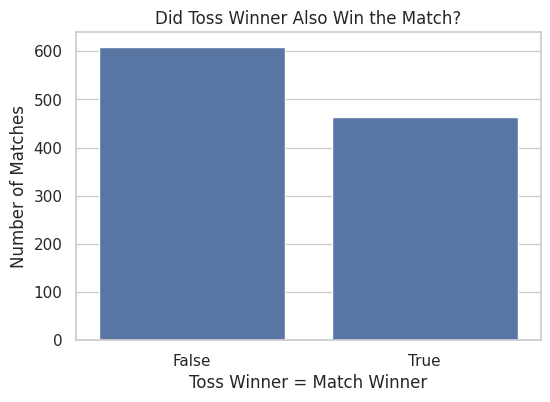

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=toss_match_win_counts,
    x="toss_winner_won_match",
    y="match_count"
)
plt.title("Did Toss Winner Also Win the Match?")
plt.xlabel("Toss Winner = Match Winner")
plt.ylabel("Number of Matches")
plt.show()


In [20]:
toss_match_win_counts["toss_winner_won_match"] = (
    toss_match_win_counts["toss_winner_won_match"]
    .map({True: "Yes", False: "No"})
)

In [21]:
print(toss_match_win_counts.head())


  toss_winner_won_match  match_count
0                    No          609
1                   Yes          464


**3B.Win Percentage After Winning the Toss**

In [22]:
toss_win_percentage = (
    clean_team["toss_and_match_win"]
    .value_counts(normalize=True)
    * 100
)

toss_win_percentage


,proportion
toss_and_match_win,
False,56.756757
True,43.243243


**3C.Batting First vs Chasing Success**

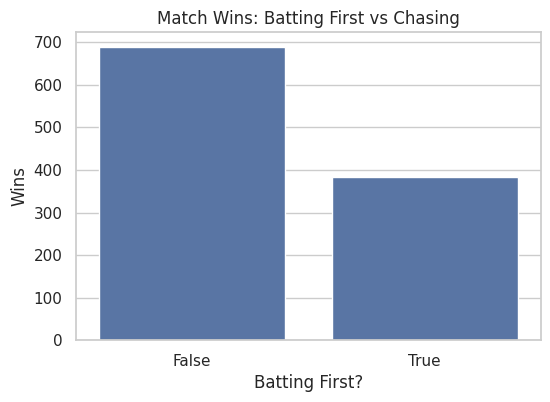

In [23]:
clean_team[toss_decision_col] = (
    clean_team[toss_decision_col]
    .astype(str)
    .str.lower()
)

clean_team["bat_first"] = clean_team[toss_decision_col] == "bat"

bat_chase_results = (
    clean_team
    .groupby("bat_first")[winner_col]
    .count()
    .reset_index()
    .rename(columns={winner_col: "wins"})
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=bat_chase_results,
    x="bat_first",
    y="wins"
)
plt.title("Match Wins: Batting First vs Chasing")
plt.xlabel("Batting First?")
plt.ylabel("Wins")
plt.show()


**3D.Toss Impact Over Seasons**

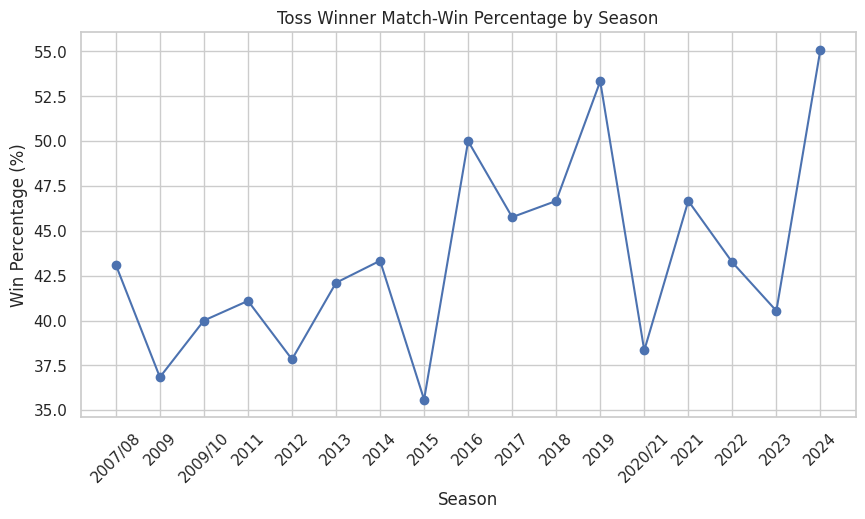

In [24]:
match_season_mapping = clean_ball[['match_id', 'season']].drop_duplicates()

clean_team_with_season = pd.merge(
    clean_team,
    match_season_mapping,
    on='match_id',
    how='left'
)

seasonal_toss_impact = (
    clean_team_with_season
    .groupby("season")["toss_and_match_win"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(
    seasonal_toss_impact["season"],
    seasonal_toss_impact["toss_and_match_win"] * 100,
    marker="o"
)
plt.title("Toss Winner Match-Win Percentage by Season")
plt.xlabel("Season")
plt.ylabel("Win Percentage (%)")
plt.xticks(rotation=45)
plt.show()

# **Insights**

* **Winning the toss provides only a marginal advantage, with toss winners winning close to half the matches, not overwhelmingly more.**

* **Chasing and batting first show comparable success rates overall, suggesting that conditions and execution matter more than the toss itself.**

* **Toss impact fluctuates across seasons, indicating that rule changes, pitches, and team strategies influence its effectiveness more than the toss alone.**

# **EDA 4: Ground / Venue Analysis**

**Step 0: Ensure venue column exists**

In [25]:
possible_venue_cols = ["venue", "stadium", "ground"]

venue_col = next(
    (c for c in possible_venue_cols if c in clean_team.columns),
    None
)

venue_col

'venue'

**4A. Average First-Innings Score by Venue**

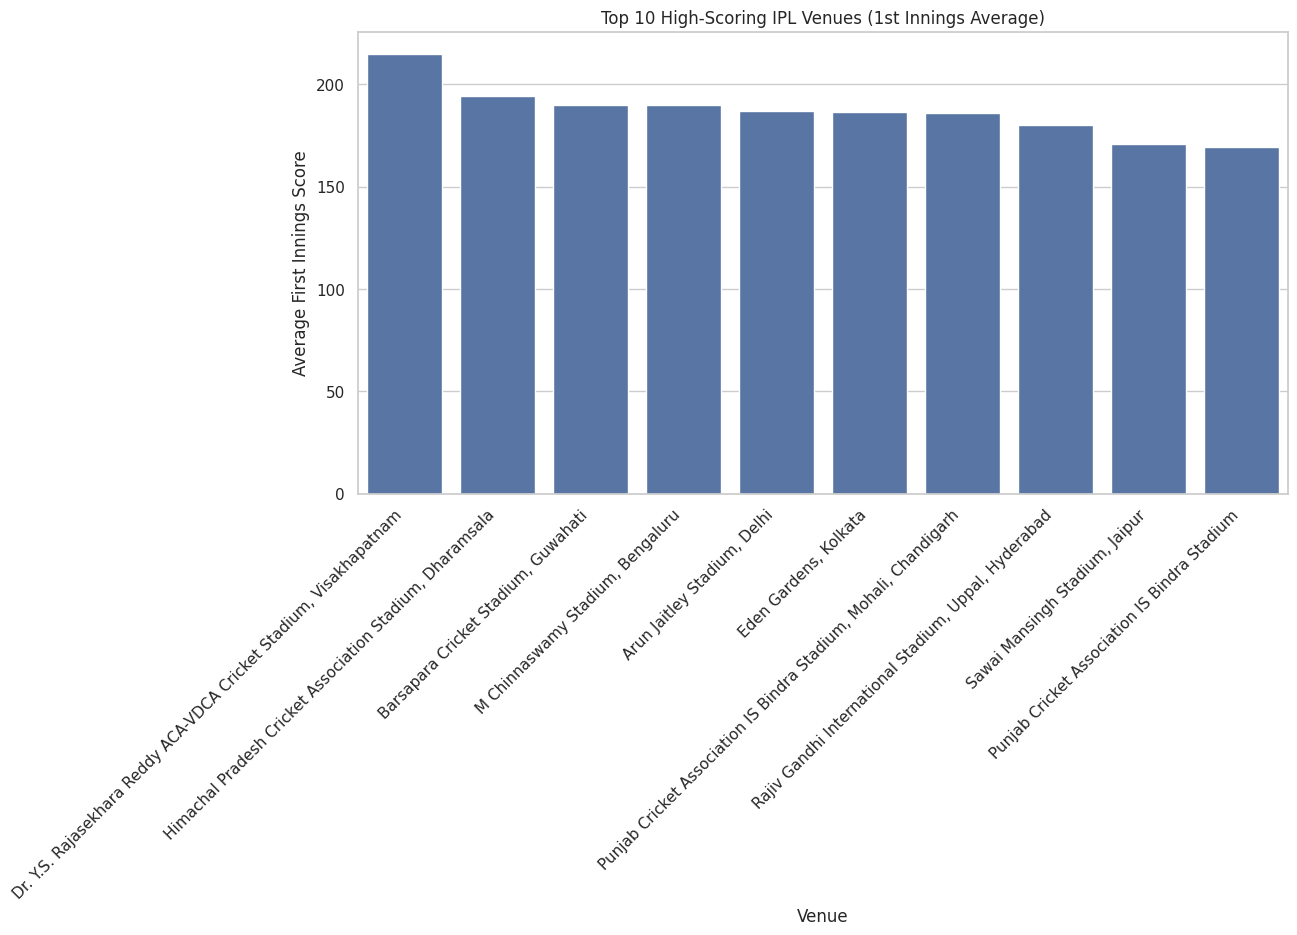

In [26]:
first_innings_scores = (
    clean_ball[clean_ball["innings_no"] == 1]
    .groupby(["match_id", "season"])["runs_scored"]
    .sum()
    .reset_index()
)

first_innings_scores = first_innings_scores.merge(
    clean_team[["match_id", venue_col]],
    on="match_id",
    how="left"
)

venue_avg_scores = (
    first_innings_scores
    .groupby(venue_col)["runs_scored"]
    .mean()
    .reset_index()
    .rename(columns={"runs_scored": "avg_first_innings_score"})
)

venue_avg_scores = venue_avg_scores.sort_values(
    by="avg_first_innings_score", ascending=False
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=venue_avg_scores.head(10),
    x=venue_col,
    y="avg_first_innings_score"
)
plt.title("Top 10 High-Scoring IPL Venues (1st Innings Average)")
plt.xlabel("Venue")
plt.ylabel("Average First Innings Score")
plt.xticks(rotation=45, ha="right")
plt.show()

**4B.Batting First vs Chasing Success by Venue**

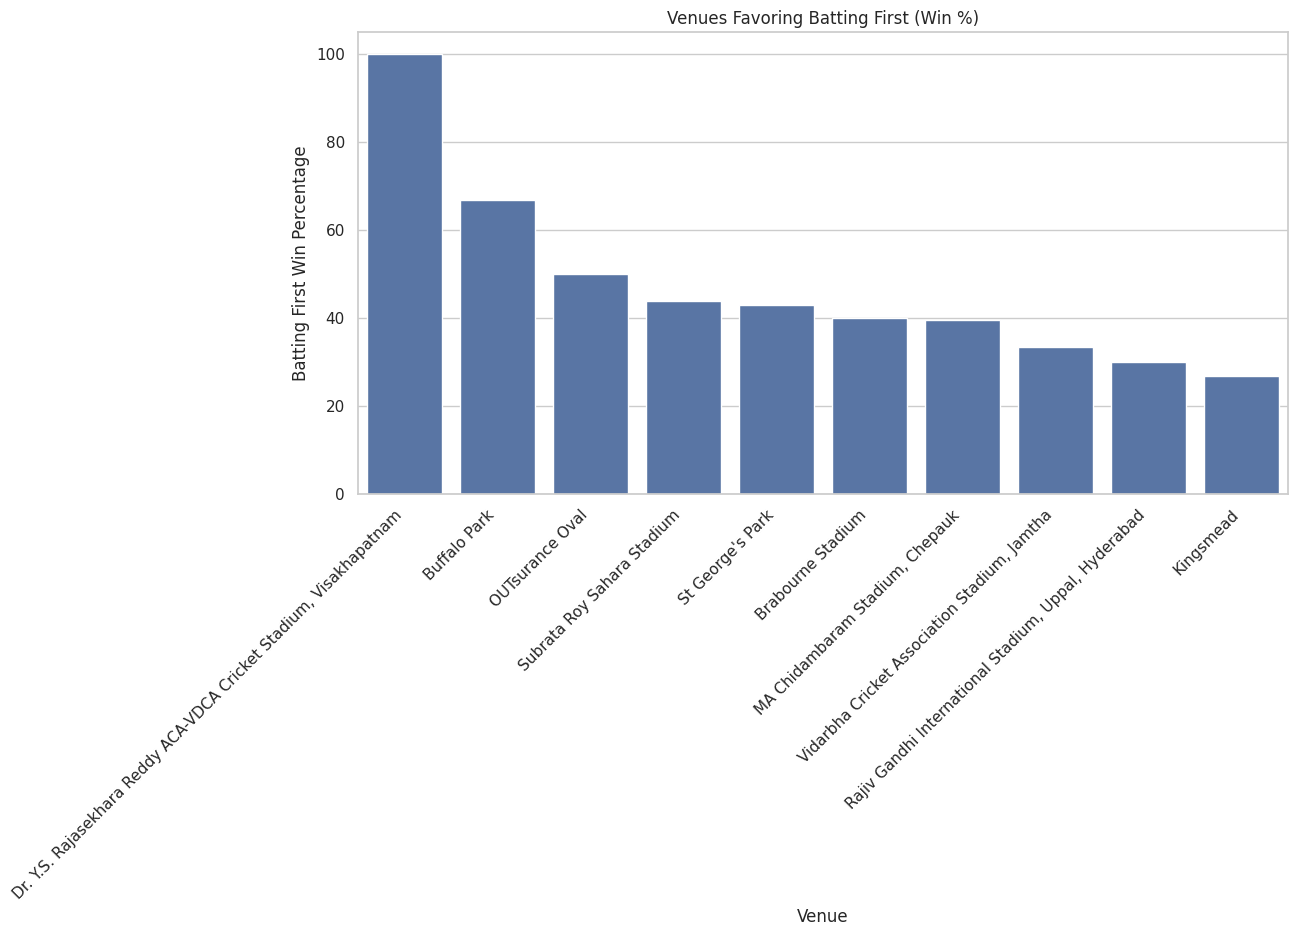

In [27]:
clean_team["winner_batted_first"] = (
    clean_team[winner_col] ==
    clean_team[toss_winner_col]
) & (clean_team[toss_decision_col] == "bat")

venue_chase_split = (
    clean_team
    .groupby(venue_col)["winner_batted_first"]
    .mean()
    .reset_index()
)

venue_chase_split["winner_batted_first"] *= 100

plt.figure(figsize=(12,6))
sns.barplot(
    data=venue_chase_split.sort_values(
        by="winner_batted_first", ascending=False
    ).head(10),
    x=venue_col,
    y="winner_batted_first"
)
plt.title("Venues Favoring Batting First (Win %)")
plt.xlabel("Venue")
plt.ylabel("Batting First Win Percentage")
plt.xticks(rotation=45, ha="right")
plt.show()

**4C.Matches Played per Venue (Context Check)**

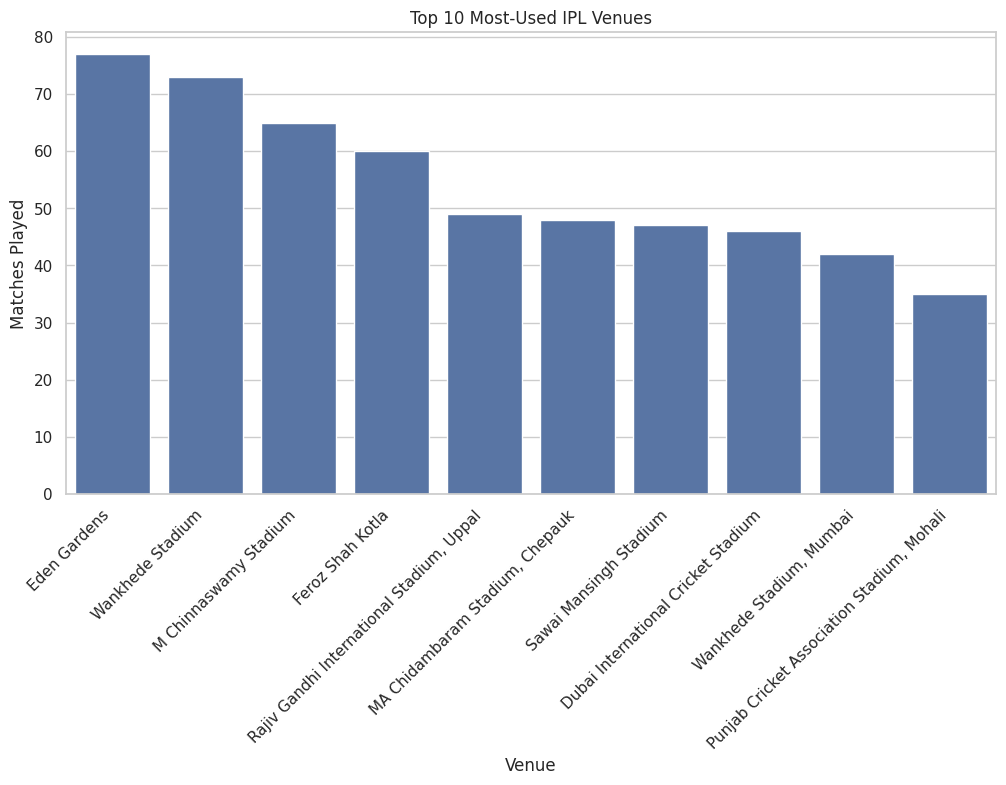

In [28]:
venue_match_counts = (
    clean_team
    .groupby(venue_col)["match_id"]
    .nunique()
    .reset_index()
    .rename(columns={"match_id": "matches"})
    .sort_values(by="matches", ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=venue_match_counts.head(10),
    x=venue_col,
    y="matches"
)
plt.title("Top 10 Most-Used IPL Venues")
plt.xlabel("Venue")
plt.ylabel("Matches Played")
plt.xticks(rotation=45, ha="right")
plt.show()

**4D.Create Team → Home Venue Mapping**

In [29]:
teams_home_venue = (
    clean_teams
    .set_index("team_full_name")["team_home_ground_(current)"]
    .to_dict()
)

teams_home_venue

{'chennai_super_kings': 'ma_chidambaram_stadium,_chennai',
 'delhi_capitals': 'arun_jaitley_stadium,_new_delhi',
 'gujarat_titans': 'narendra_modi_stadium,_ahmedabad',
 'kolkata_knight_riders': 'eden_gardens,_kolkata',
 'lucknow_super_giants': 'br_sabv_ekana_cricket_stadium,_lucknow',
 'mumbai_indians': 'wankhede_stadium,_mumbai',
 'punjab_kings': 'pca_new_stadium,_mullanpur',
 'rajasthan_royals': 'sawai_mansingh_stadium,_jaipur',
 'royal_challengers_bengaluru': 'm_chinnaswamy_stadium,_bengaluru',
 'sunrisers_hyderabad': 'rajiv_gandhi_international_cricket_stadium,_hyderabad'}

**4E.Flag Home Matches**

In [30]:
team_name_standardization = {
    'chennai_super_kings': 'chennai_super_kings',
    'delhi_capitals': 'delhi_capitals',
    'delhi_daredevils': 'delhi_capitals',
    'gujarat_titans': 'gujarat_titans',
    'kolkata_knight_riders': 'kolkata_knight_riders',
    'lucknow_super_giants': 'lucknow_super_giants',
    'mumbai_indians': 'mumbai_indians',
    'punjab_kings': 'punjab_kings',
    'kings_xi_पंजाब': 'punjab_kings',
    'rajasthan_royals': 'rajasthan_royals',
    'royal_challengers_bengaluru': 'royal_challengers_bengaluru',
    'royal_challengers_bangalore': 'royal_challengers_bengaluru',
    'sunrisers_hyderabad': 'sunrisers_hyderabad',
    'deccan_chargers': 'sunrisers_hyderabad',
    'rising_pune_supergiants': 'rising_pune_supergiants',
    'rising_pune_supergiant': 'rising_pune_supergiants',
    'gujarat_lions': 'defunct',
    'kochi_tuskers_kerala': 'defunct',
    'pune_warriors': 'defunct',
    'draw/no_result': 'draw/no_result'
}

clean_team['temp_winner_col_normalized'] = (
    clean_team[winner_col]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

clean_team[winner_col] = clean_team['temp_winner_col_normalized'].map(team_name_standardization)
clean_team[venue_col] = (
    clean_team[venue_col]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

clean_team["home_venue"] = clean_team[winner_col].map(teams_home_venue)

clean_team["is_home_match"] = (
    clean_team[venue_col] == clean_team["home_venue"]
)
clean_team.drop(columns=['temp_winner_col_normalized'], inplace=True, errors='ignore')

**4F.Venue-wise Team Dominance**

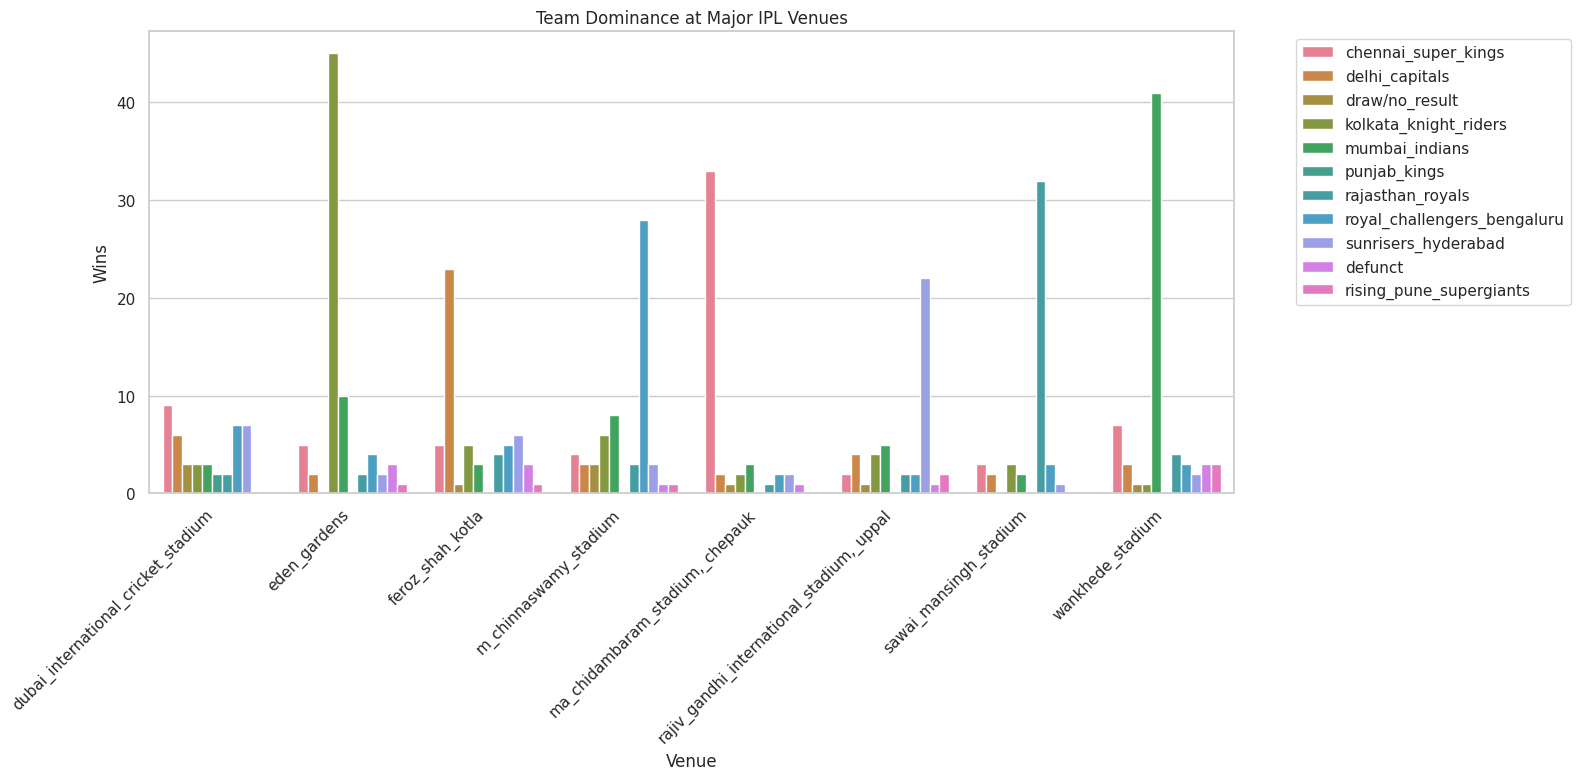

In [31]:
venue_team_wins = (
    clean_team
    .groupby([venue_col, winner_col])["match_id"]
    .count()
    .reset_index()
    .rename(columns={
        venue_col: "venue",
        winner_col: "team",
        "match_id": "wins"
    })
)
top_venues = (
    clean_team[venue_col]
    .value_counts()
    .head(8)
    .index
)

venue_team_wins = venue_team_wins[
    venue_team_wins["venue"].isin(top_venues)
]

plt.figure(figsize=(14,6))
sns.barplot(
    data=venue_team_wins,
    x="venue",
    y="wins",
    hue="team"
)
plt.title("Team Dominance at Major IPL Venues")
plt.xlabel("Venue")
plt.ylabel("Wins")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


#**EDA 5: Phase-wise Match Analysis (Powerplay, Middle Overs, Death Overs)**

**Phase Definitions**

1. Powerplay: Overs 1–6

2. Middle Overs: Overs 7–15

3. Death Overs: Overs 16–20


**Step 0: Create Phase Column (once, reusable)**

In [32]:
def assign_phase(over_num):
    if 1 <= over_num <= 6:
        return "Powerplay"
    elif 7 <= over_num <= 15:
        return "Middle Overs"
    else:
        return "Death Overs"

clean_ball["phase"] = clean_ball["ball_no"].apply(lambda x: int(x) + 1).apply(assign_phase)

**5A.Average Runs per Over by Phase**

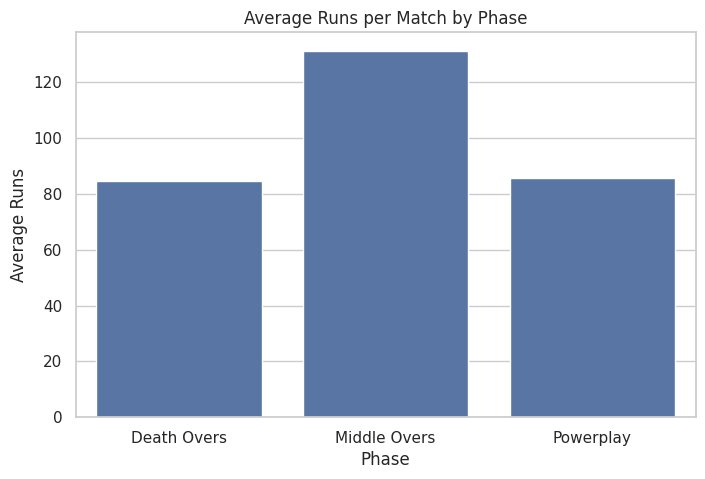

In [33]:
phase_runs = (
    clean_ball
    .groupby(["phase", "match_id"])["runs_scored"]
    .sum()
    .reset_index()
    .groupby("phase")["runs_scored"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=phase_runs,
    x="phase",
    y="runs_scored"
)
plt.title("Average Runs per Match by Phase")
plt.xlabel("Phase")
plt.ylabel("Average Runs")
plt.show()


**5B.Wickets per Phase (Pressure Indicator)**

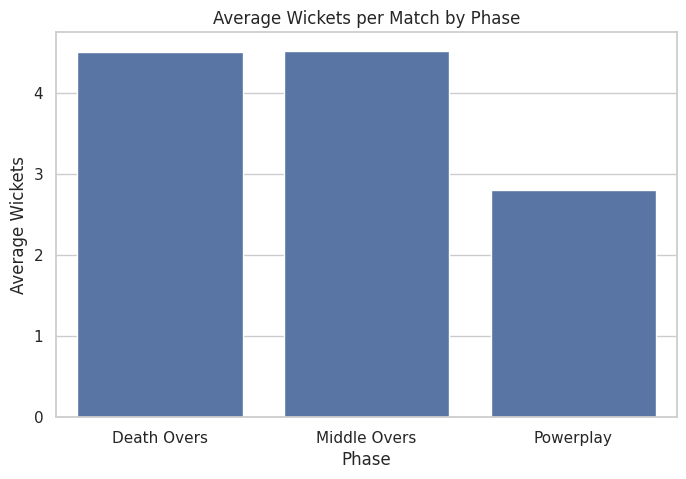

In [34]:
clean_ball["is_wicket"] = clean_ball["player_out"].notna().astype(int)

phase_wickets = (
    clean_ball
    .groupby(["phase", "match_id"])["is_wicket"]
    .sum()
    .reset_index()
    .groupby("phase")["is_wicket"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=phase_wickets,
    x="phase",
    y="is_wicket"
)
plt.title("Average Wickets per Match by Phase")
plt.xlabel("Phase")
plt.ylabel("Average Wickets")
plt.show()

**5C.Phase Dominance vs Match Result (Winning Teams)**

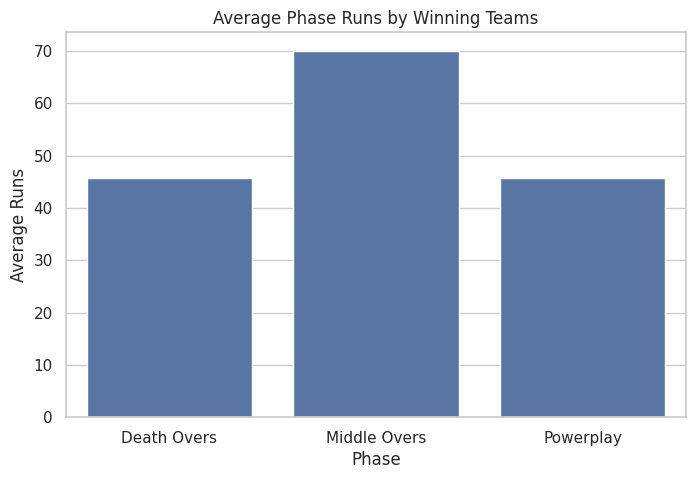

In [35]:
ball_with_winner = clean_ball.merge(
    clean_team[["match_id", winner_col]],
    on="match_id",
    how="left"
)
winning_team_phase_runs = (
    ball_with_winner[
        ball_with_winner["batting_team"] == ball_with_winner[winner_col]
    ]
    .groupby(["phase", "match_id"])["runs_scored"]
    .sum()
    .reset_index()
    .groupby("phase")["runs_scored"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=winning_team_phase_runs,
    x="phase",
    y="runs_scored"
)
plt.title("Average Phase Runs by Winning Teams")
plt.xlabel("Phase")
plt.ylabel("Average Runs")
plt.show()

# **Insights**

* **While the powerplay sets the foundation, the middle overs contribute the largest share of total runs, making them critical for match control.**

* **Death overs are the most volatile phase, with high scoring and wicket loss, often deciding close matches.**

* **Winning teams consistently outperform opponents in middle and death overs, indicating that match outcomes depend more on finishing strength than early momentum.**

# **EDA 6: Batting Analysis (Top Batters & Roles)**




**Step 0: Create Batter-Level Aggregates**

In [36]:
batter_stats = (
    clean_ball
    .groupby("striker")
    .agg(
        runs=("runs_scored", "sum"),
        balls=("runs_scored", "count")
    )
    .reset_index()
)

batter_stats["strike_rate"] = (
    batter_stats["runs"] / batter_stats["balls"]
) * 100

**6A.Top Batters by Total Runs (with threshold)**

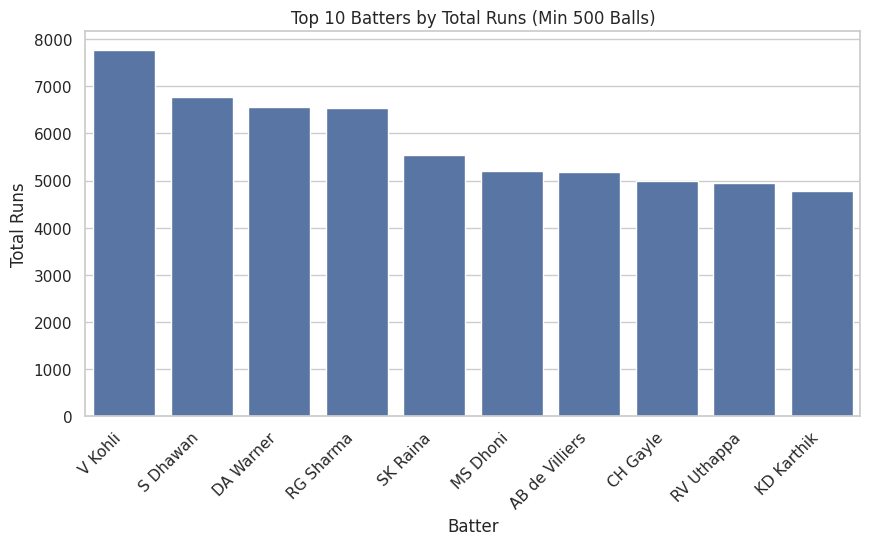

In [37]:
min_balls = 500

top_run_scorers = batter_stats[
    batter_stats["balls"] >= min_balls
].sort_values(by="runs", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_run_scorers,
    x="striker",
    y="runs"
)
plt.title("Top 10 Batters by Total Runs (Min 500 Balls)")
plt.xlabel("Batter")
plt.ylabel("Total Runs")
plt.xticks(rotation=45, ha="right")
plt.show()

**6B.Most Explosive Batters (Strike Rate Focus)**

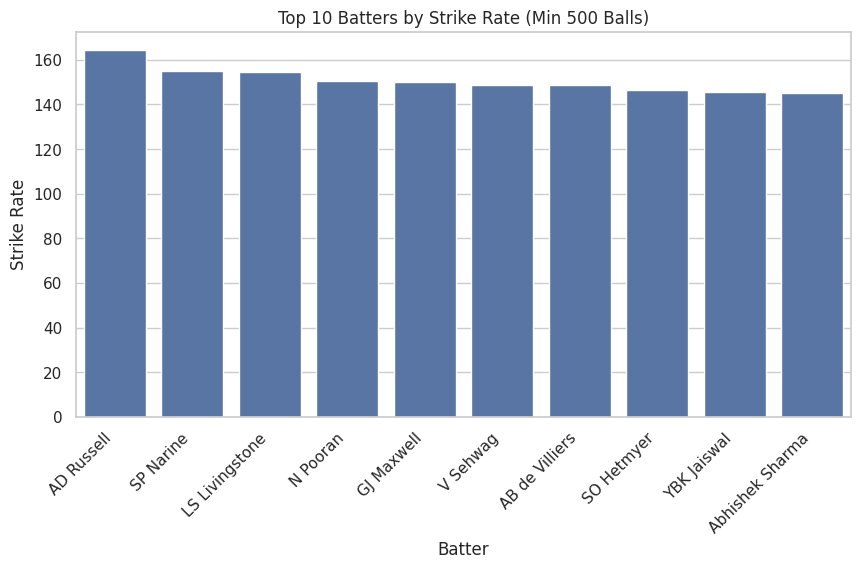

In [38]:
top_strike_rate = batter_stats[
    batter_stats["balls"] >= min_balls
].sort_values(by="strike_rate", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_strike_rate,
    x="striker",
    y="strike_rate"
)
plt.title("Top 10 Batters by Strike Rate (Min 500 Balls)")
plt.xlabel("Batter")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

**6C.Phase-wise Batting Contribution**

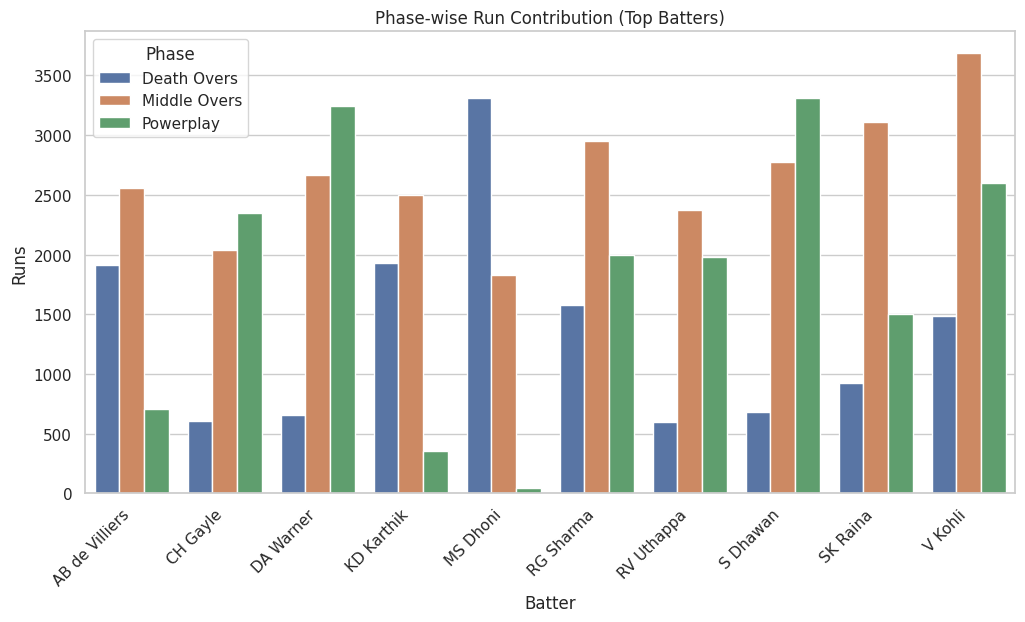

In [39]:
batter_phase_runs = (
    clean_ball
    .groupby(["striker", "phase"])["runs_scored"]
    .sum()
    .reset_index()
)
top_batters = top_run_scorers["striker"].tolist()

batter_phase_runs = batter_phase_runs[
    batter_phase_runs["striker"].isin(top_batters)
]

plt.figure(figsize=(12,6))
sns.barplot(
    data=batter_phase_runs,
    x="striker",
    y="runs_scored",
    hue="phase"
)
plt.title("Phase-wise Run Contribution (Top Batters)")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Phase")
plt.show()

# **Insights**

* **High total run scorers demonstrate longevity and consistency, often anchoring their teams across seasons.**

* **High strike-rate batters provide situational impact, particularly valuable in middle and death overs.**

* **Phase-wise analysis reveals clear role specialization, distinguishing anchors from finishers rather than ranking all batters on a single metric.**

# **EDA 7: Bowling Analysis (Top Bowlers & Death Specialists)**





**Step 0: Create Bowler-Level Base Stats**

In [40]:
bowler_wickets = clean_ball[
    (clean_ball["player_out"].notna()) &
    (clean_ball["wicket_type"] != "run out")
]

bowler_stats = (
    clean_ball
    .groupby("bowler")
    .agg(
        runs_conceded=("runs_scored", "sum"),
        balls=("runs_scored", "count")
    )
    .reset_index()
)

wicket_counts = (
    bowler_wickets
    .groupby("bowler")["player_out"]
    .count()
    .reset_index()
    .rename(columns={"player_out": "wickets"})
)

bowler_stats = bowler_stats.merge(
    wicket_counts, on="bowler", how="left"
).fillna(0)

bowler_stats["overs"] = bowler_stats["balls"] / 6
bowler_stats["economy"] = bowler_stats["runs_conceded"] / bowler_stats["overs"]

**7A.Top Bowlers by Wickets (with threshold)**

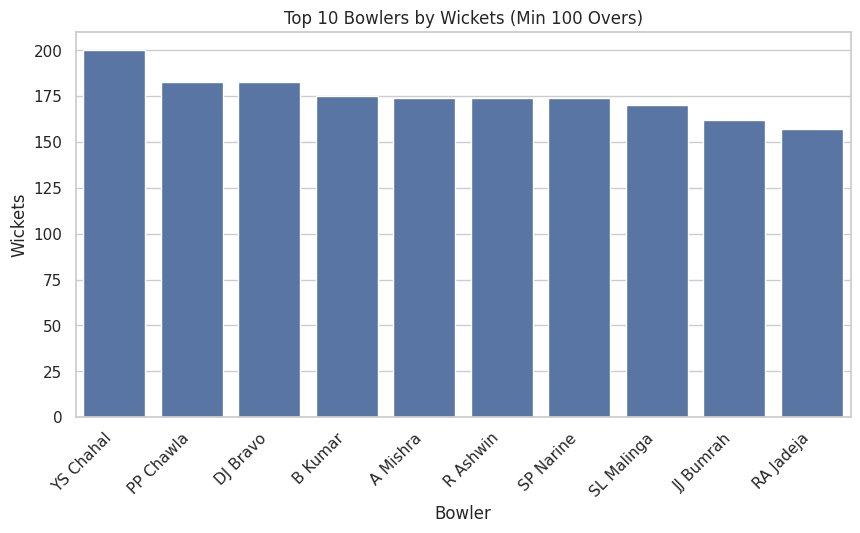

In [41]:
min_overs = 100

top_wicket_takers = bowler_stats[
    bowler_stats["overs"] >= min_overs
].sort_values(by="wickets", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_wicket_takers,
    x="bowler",
    y="wickets"
)
plt.title("Top 10 Bowlers by Wickets (Min 100 Overs)")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45, ha="right")
plt.show()

**7B.Most Economical Bowlers (Control Specialists)**

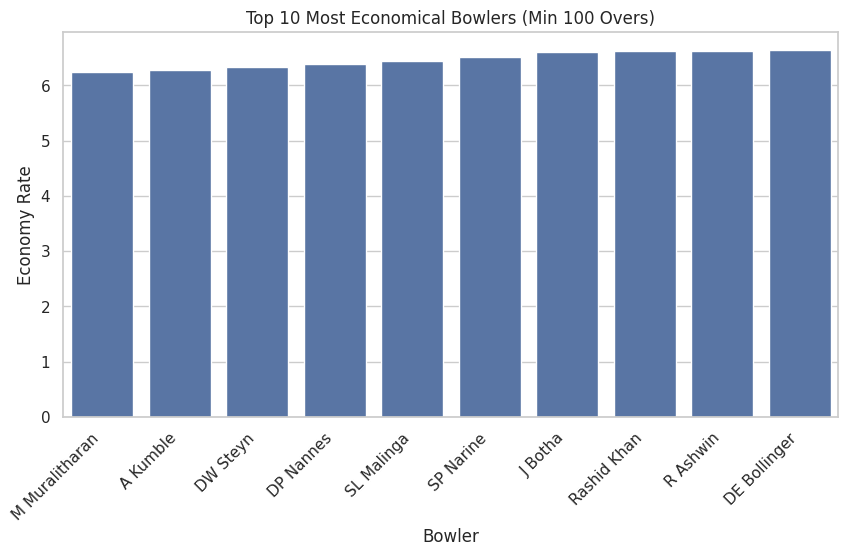

In [42]:
min_overs = 100
best_economy = bowler_stats[
    bowler_stats["overs"] >= min_overs
].sort_values(by="economy").head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=best_economy,
    x="bowler",
    y="economy"
)
plt.title("Top 10 Most Economical Bowlers (Min 100 Overs)")
plt.xlabel("Bowler")
plt.ylabel("Economy Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

**7C.Death Overs Specialists (Overs 16–20)**

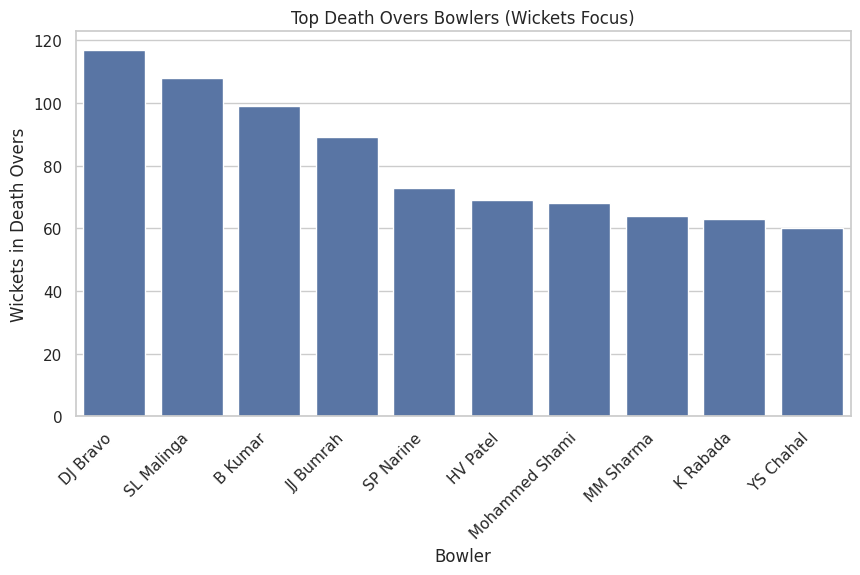

In [43]:
death_overs = clean_ball[
    clean_ball["phase"] == "Death Overs"
]

death_wickets = death_overs[
    (death_overs["player_out"].notna()) &
    (death_overs["wicket_type"] != "run out")
]

death_bowler_stats = (
    death_overs
    .groupby("bowler")
    .agg(
        runs_conceded=("runs_scored", "sum"),
        balls=("runs_scored", "count")
    )
    .reset_index()
)

death_wicket_counts = (
    death_wickets
    .groupby("bowler")["player_out"]
    .count()
    .reset_index()
    .rename(columns={"player_out": "wickets"})
)

death_bowler_stats = death_bowler_stats.merge(
    death_wicket_counts, on="bowler", how="left"
).fillna(0)

death_bowler_stats["overs"] = death_bowler_stats["balls"] / 6
death_bowler_stats["economy"] = (
    death_bowler_stats["runs_conceded"] /
    death_bowler_stats["overs"]
)

death_min_overs = 30

top_death_bowlers = death_bowler_stats[
    death_bowler_stats["overs"] >= death_min_overs
].sort_values(by=["wickets", "economy"], ascending=[False, True]).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_death_bowlers,
    x="bowler",
    y="wickets"
)
plt.title("Top Death Overs Bowlers (Wickets Focus)")
plt.xlabel("Bowler")
plt.ylabel("Wickets in Death Overs")
plt.xticks(rotation=45, ha="right")
plt.show()

# **Insights**

* **High wicket-taking bowlers provide breakthrough value, often changing match momentum.**

* **Economical bowlers contribute through run control, even without frequent wickets, especially in middle overs.**

* **Death overs specialists combine wicket-taking under pressure with acceptable economy, making them among the most valuable assets in T20 cricket.**

#**EDA 8: Player Deep-Dive Analysis (Legendary Batters & Bowlers)**

**Players Selected**

**Batters**

1. Virat Kohli

2. Rohit Sharma

3. Suresh Raina

4. MS Dhoni

5. Shikhar Dhawan

**Bowlers**

1. Jasprit Bumrah

2. Yuzvendra Chahal

3. Bhuvneshwar Kumar

4. Ravichandran Ashwin

5. Ravindra Jadeja



**8A: Batters Deep Dive Analysis**

**Step 1: Filter Selected Batters**

In [44]:
selected_batters = [
    "V Kohli",
    "RG Sharma",
    "S Dhawan",
    "SK Raina",
    "MS Dhoni"
]

batter_df = clean_ball[
    clean_ball["striker"].isin(selected_batters)
].copy()


In [45]:
batter_df["striker"].unique()


array(['V Kohli', 'MS Dhoni', 'SK Raina', 'S Dhawan', 'RG Sharma'],
      dtype=object)

**Step 2: Runs per Season (Longevity & Peaks)**

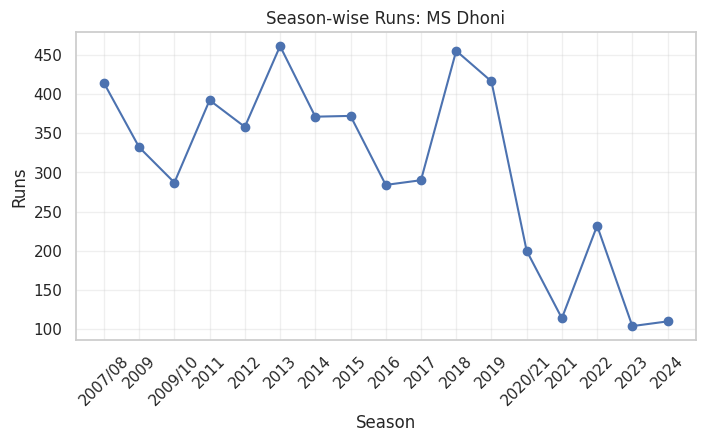

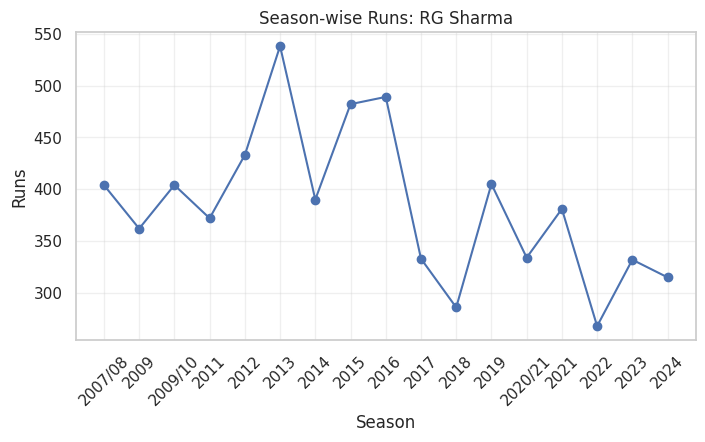

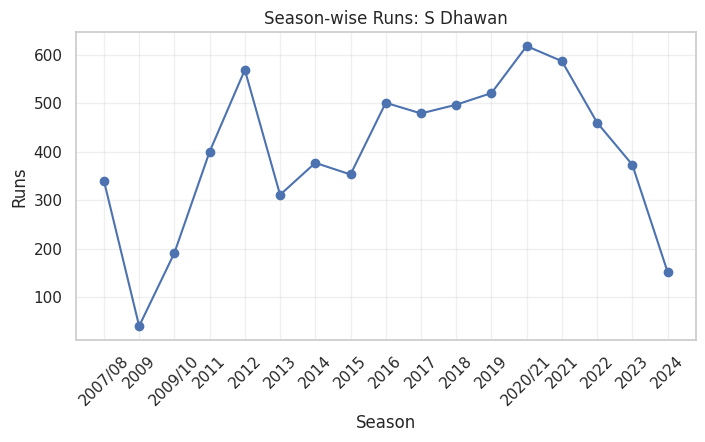

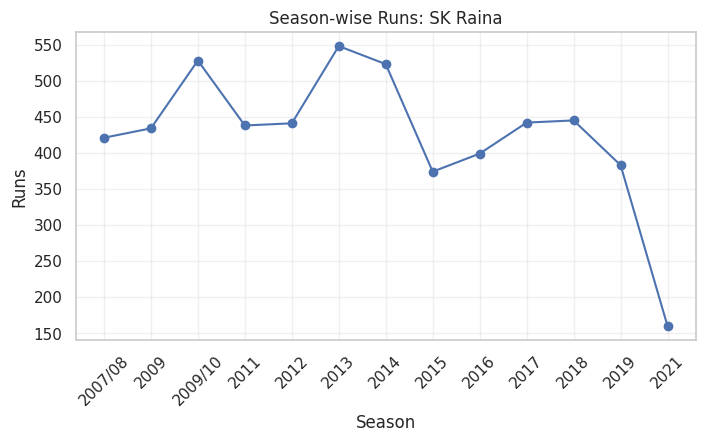

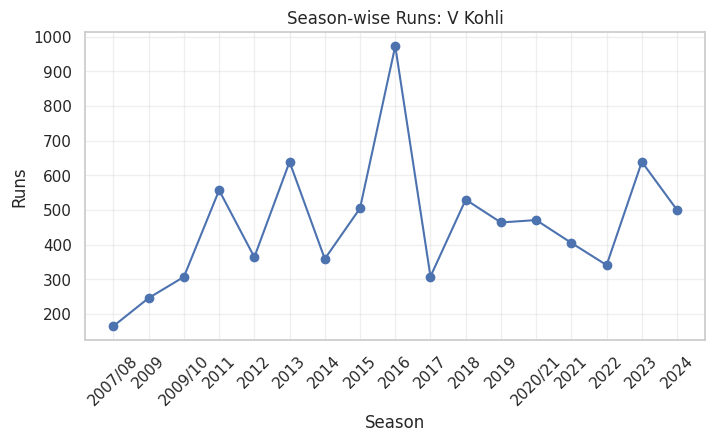

In [46]:
batter_season_runs = (
    batter_df
    .groupby(["striker", "season"])["runs_scored"]
    .sum()
    .reset_index()
)

for batter in batter_season_runs["striker"].unique():
    player_data = batter_season_runs[
        batter_season_runs["striker"] == batter
    ]

    plt.figure(figsize=(8,4))
    plt.plot(
        player_data["season"],
        player_data["runs_scored"],
        marker="o"
    )
    plt.title(f"Season-wise Runs: {batter}")
    plt.xlabel("Season")
    plt.ylabel("Runs")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.show()

**Step 3: Phase-wise Contribution (Roles)**

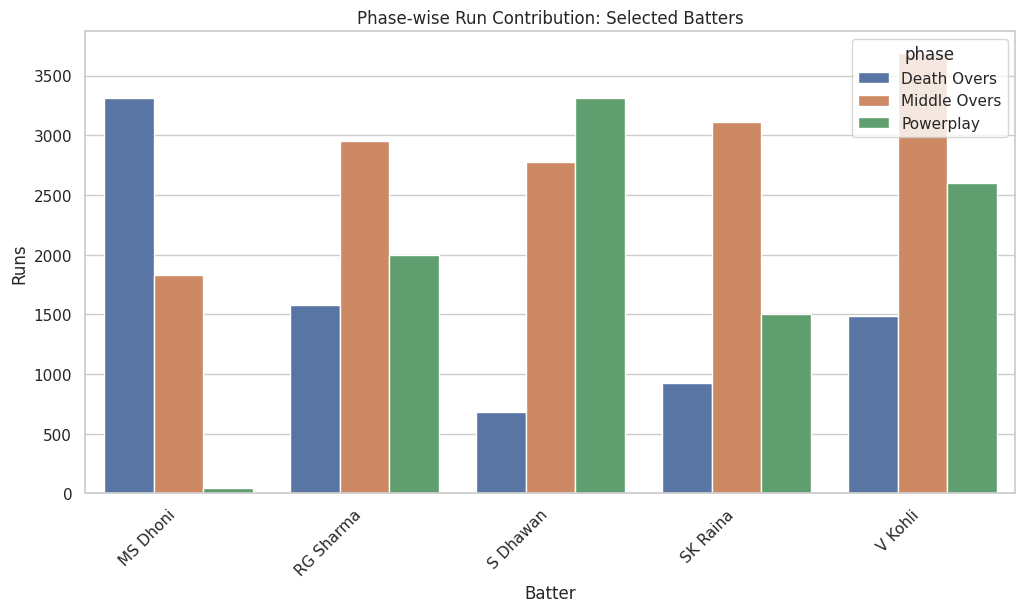

In [47]:
batter_phase_runs = (
    batter_df
    .groupby(["striker", "phase"])["runs_scored"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=batter_phase_runs,
    x="striker",
    y="runs_scored",
    hue="phase"
)
plt.title("Phase-wise Run Contribution: Selected Batters")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45, ha="right")
plt.show()


# **Batting Insights**

* **Virat Kohli and Shikhar Dhawan show exceptional consistency across seasons, reflecting anchor roles.**

* MS Dhoni contributes disproportionately in the death overs, confirming his finisher profile.**

* **Suresh Raina dominates middle overs, while Rohit Sharma balances powerplay aggression with longevity.**

**8B: Bowlers Deep Dive Analysis**

**Step 1: Filter bowlers**

In [48]:
selected_bowlers = [
    "YS Chahal",
    "B Kumar",
    "JJ Bumrah",
    "R Ashwin",
    "RA Jadeja"
]

bowler_df = clean_ball[
    clean_ball["bowler"].isin(selected_bowlers)
].copy()

In [49]:
bowler_df["bowler"].unique()

array(['RA Jadeja', 'R Ashwin', 'B Kumar', 'JJ Bumrah', 'YS Chahal'],
      dtype=object)

**Step 2: Wickets per Season**

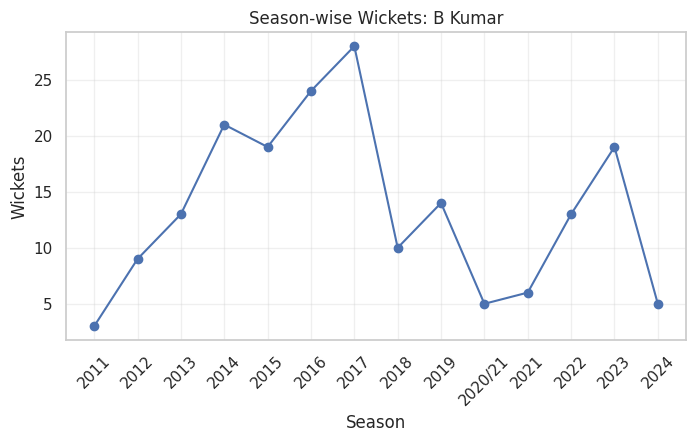

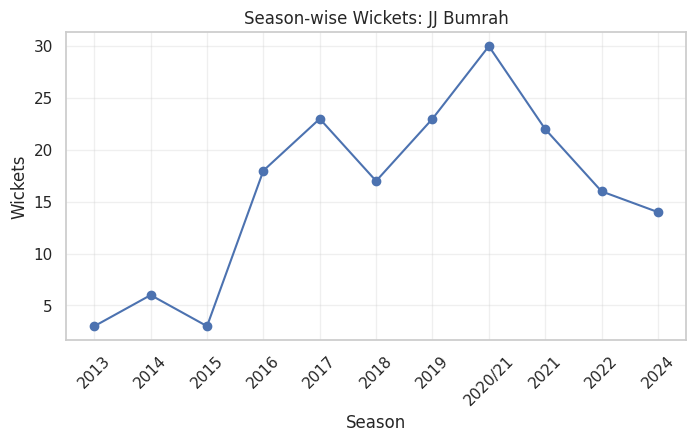

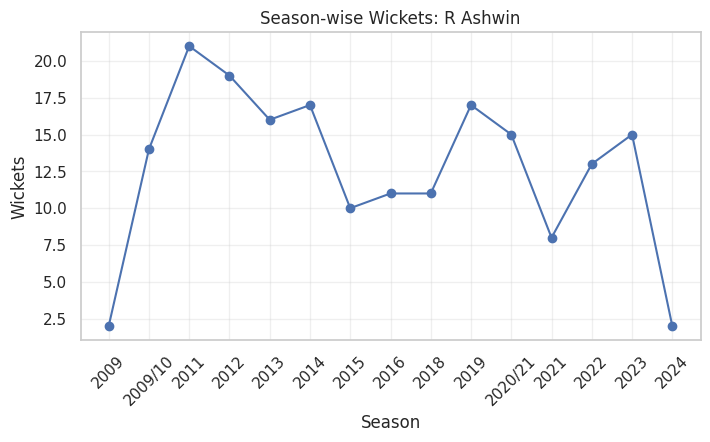

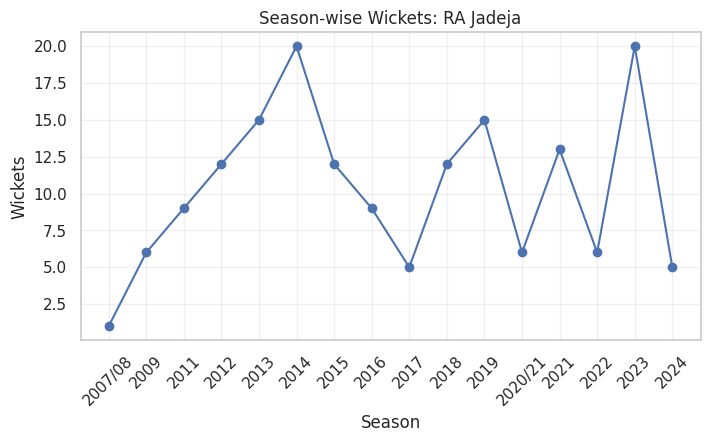

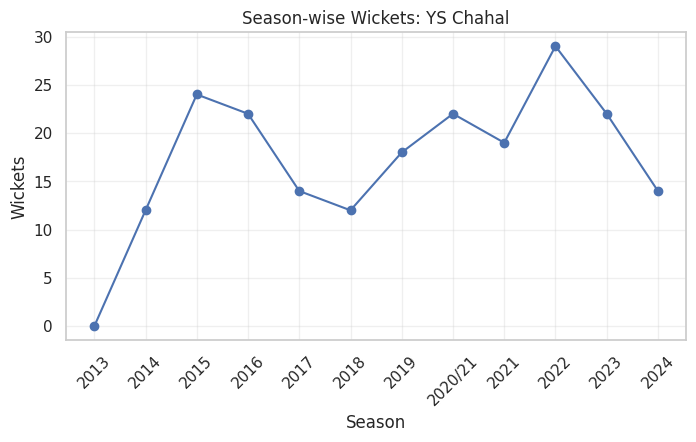

In [50]:
bowler_season_wickets = (
    bowler_df
    .groupby(["bowler", "season"])["is_wicket"]
    .sum()
    .reset_index()
)

for bowler in bowler_season_wickets["bowler"].unique():
    player_data = bowler_season_wickets[
        bowler_season_wickets["bowler"] == bowler
    ]

    plt.figure(figsize=(8,4))
    plt.plot(
        player_data["season"],
        player_data["is_wicket"],
        marker="o"
    )
    plt.title(f"Season-wise Wickets: {bowler}")
    plt.xlabel("Season")
    plt.ylabel("Wickets")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.show()


**Step 3: Phase-wise Bowling Impact**

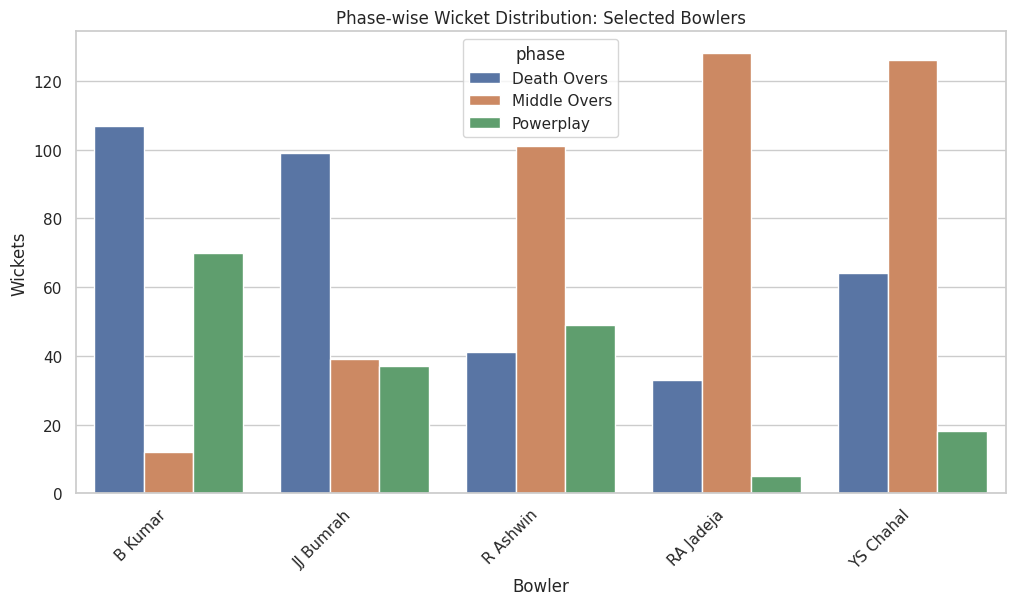

In [51]:
bowler_phase_wickets = (
    bowler_df
    .groupby(["bowler", "phase"])["is_wicket"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=bowler_phase_wickets,
    x="bowler",
    y="is_wicket",
    hue="phase"
)
plt.title("Phase-wise Wicket Distribution: Selected Bowlers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45, ha="right")
plt.show()


# **Bowling Insights**

* **Bumrah dominates death overs with high wicket impact and control, making him uniquely valuable.**

* **Chahal and Ashwin peak in middle overs, exploiting batters during consolidation phases.**

* **Jadeja combines wicket-taking with control, reinforcing his role as a high-impact all-rounder.**